In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("loan.csv", low_memory=False)
df.shape

(2260701, 151)

In [3]:
df["loan_status"].value_counts()

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [4]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
df["target"] = (df["loan_status"] == "Charged Off").astype(int)
df.shape

(1345310, 152)

In [6]:
NUMERIC_FEATURES = [
    "loan_amnt", "int_rate", "annual_inc", "dti",
    "fico_range_low", "fico_range_high", "revol_util",
    "total_acc", "open_acc", "delinq_2yrs", "inq_last_6mths"
]

CATEGORICAL_FEATURES = [
    "emp_length", "home_ownership", "purpose"
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

In [7]:
df = df[FEATURES + ["target"]].copy()

In [8]:
df = df.dropna(subset=["target"])

for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=NUMERIC_FEATURES)
df.shape

(1344079, 15)

In [9]:
df.head()

,loan_amnt,int_rate,annual_inc,dti,fico_range_low,fico_range_high,revol_util,total_acc,open_acc,delinq_2yrs,inq_last_6mths,emp_length,home_ownership,purpose,target
0,3600.0,13.99,55000.0,5.91,675.0,679.0,29.7,13.0,7.0,0.0,1.0,10+ years,MORTGAGE,debt_consolidation,0
1,24700.0,11.99,65000.0,16.06,715.0,719.0,19.2,38.0,22.0,1.0,4.0,10+ years,MORTGAGE,small_business,0
2,20000.0,10.78,63000.0,10.78,695.0,699.0,56.2,18.0,6.0,0.0,0.0,10+ years,MORTGAGE,home_improvement,0
4,10400.0,22.45,104433.0,25.37,695.0,699.0,64.5,35.0,12.0,1.0,3.0,3 years,MORTGAGE,major_purchase,0
5,11950.0,13.44,34000.0,10.20,690.0,694.0,68.4,6.0,5.0,0.0,0.0,4 years,RENT,debt_consolidation,0


In [10]:
df["target"].value_counts(normalize=True)

,proportion
target,
0,0.800378
1,0.199622


In [11]:
X = df[FEATURES]
y = df["target"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((1075263, 14), (268816, 14))

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES)
])

In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((1075263, 42), (268816, 42))

In [15]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
scale_pos_weight

np.float64(4.009471408738109)

In [16]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    use_label_encoder=False
)

model.fit(X_train_processed, y_train)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [15:54:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

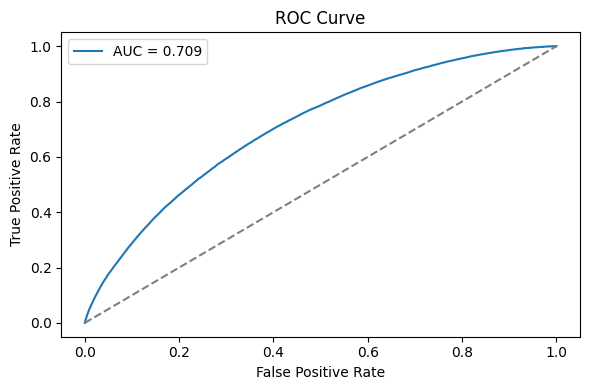

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
def probability_to_score(probability):
    min_score = 300
    max_score = 850
    score = max_score - (max_score - min_score) * probability
    return int(round(score))

def score_to_risk_band(score):
    if score >= 750:
        return "Very Low Risk"
    elif score >= 700:
        return "Low Risk"
    elif score >= 650:
        return "Medium Risk"
    elif score >= 600:
        return "High Risk"
    else:
        return "Very High Risk"

def get_decision(score):
    if score >= 650:
        return "Approve"
    elif score >= 600:
        return "Manual Review"
    else:
        return "Decline"

In [20]:
sample_proba = float(y_pred_proba[0])
sample_score = probability_to_score(sample_proba)
sample_band = score_to_risk_band(sample_score)
sample_decision = get_decision(sample_score)

sample_proba, sample_score, sample_band, sample_decision

(0.6155312657356262, 511, 'Very High Risk', 'Decline')

In [21]:
import shap

explainer = shap.TreeExplainer(model)

In [22]:
sample_index = 0
sample_processed = X_test_processed[sample_index:sample_index + 1]

shap_values = explainer.shap_values(sample_processed)
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_values

array([[ 2.4535534e-01,  1.2265294e-01,  1.3276984e-01, -5.6593921e-02,
        -1.3934074e-01,  0.0000000e+00,  8.9018203e-02,  7.4852809e-02,
        -4.6270996e-02, -7.3492271e-03, -4.7365166e-02, -8.7351992e-04,
        -1.7980583e-02,  4.5214151e-04, -1.6293392e-05,  1.5996673e-05,
         1.1708028e-04,  1.0886773e-03, -2.9140308e-05,  8.6361833e-06,
        -7.7758623e-06, -8.7052671e-04,  0.0000000e+00,  7.7102892e-02,
         0.0000000e+00,  0.0000000e+00, -2.0459102e-04,  5.8333449e-02,
         3.7181599e-04,  1.6486023e-03, -4.3429201e-03,  0.0000000e+00,
        -2.3973878e-03,  2.1709001e-04, -1.2413132e-03, -1.4140250e-03,
        -7.8431360e-04, -1.5617770e-03, -2.6704165e-05, -3.5993606e-03,
        -1.1189930e-03,  6.6418148e-04]], dtype=float32)

In [23]:
num_names = NUMERIC_FEATURES
cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
feature_names = num_names + cat_names

len(feature_names), len(shap_values[0])

(42, 42)

In [24]:
contributions = pd.DataFrame({
    "feature": feature_names,
    "shap_value": shap_values[0]
})

contributions["abs_shap"] = contributions["shap_value"].abs()
contributions = contributions.sort_values("abs_shap", ascending=False)
contributions.head(10)

,feature,shap_value,abs_shap
0,loan_amnt,0.245355,0.245355
4,fico_range_low,-0.139341,0.139341
2,annual_inc,0.132770,0.132770
1,int_rate,0.122653,0.122653
6,revol_util,0.089018,0.089018
23,home_ownership_MORTGAGE,0.077103,0.077103
7,total_acc,0.074853,0.074853
27,home_ownership_RENT,0.058333,0.058333
3,dti,-0.056594,0.056594
10,inq_last_6mths,-0.047365,0.047365


In [25]:
shap.initjs()
shap.force_plot(
    explainer.expected_value if not isinstance(explainer.expected_value, list)
    else explainer.expected_value[1],
    shap_values[0],
    sample_processed[0],
    feature_names=feature_names
)

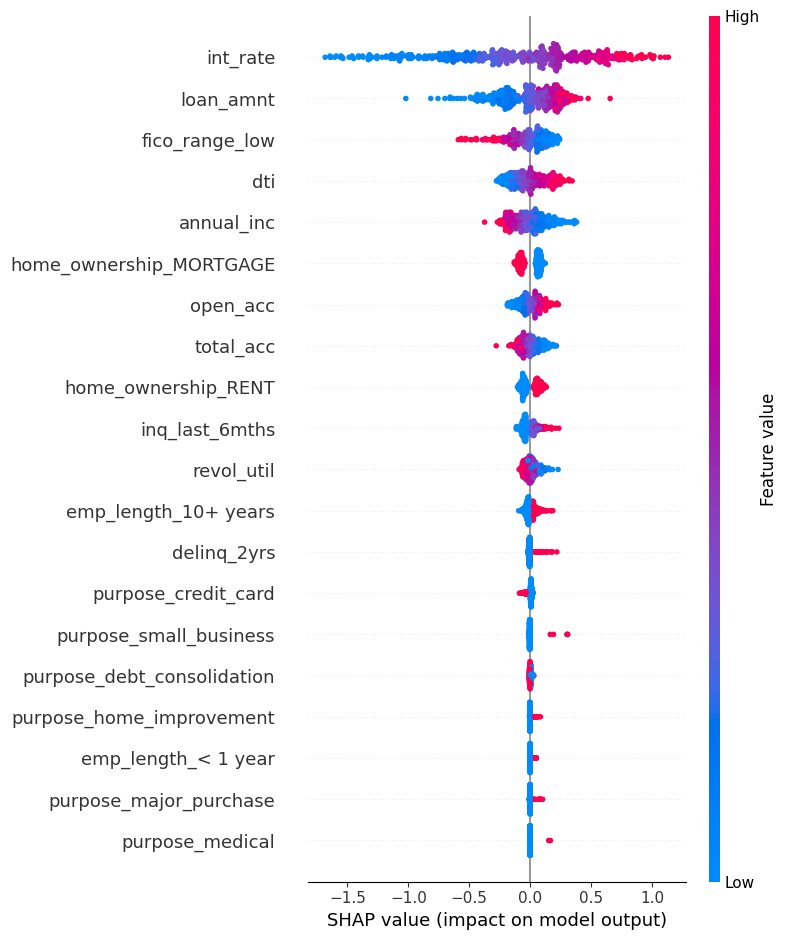

In [26]:
sample_size = 500
X_sample = X_test_processed[:sample_size]

shap_values_sample = explainer.shap_values(X_sample)
if isinstance(shap_values_sample, list):
    shap_values_sample = shap_values_sample[1]

shap.summary_plot(shap_values_sample, X_sample, feature_names=feature_names)

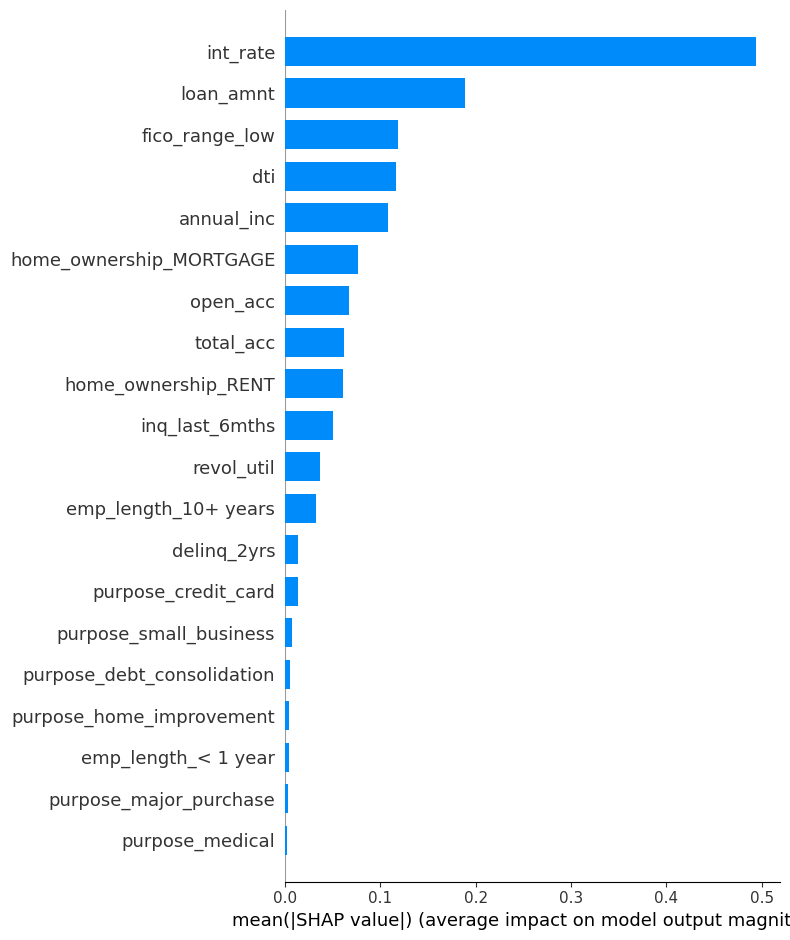

In [27]:
shap.summary_plot(
    shap_values_sample, X_sample,
    feature_names=feature_names,
    plot_type="bar"
)

In [28]:
global_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values_sample).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

global_importance.head(15)

,feature,mean_abs_shap
1,int_rate,0.494503
0,loan_amnt,0.188564
4,fico_range_low,0.118451
3,dti,0.115911
2,annual_inc,0.108275
23,home_ownership_MORTGAGE,0.076793
8,open_acc,0.067101
7,total_acc,0.061640
27,home_ownership_RENT,0.060797
10,inq_last_6mths,0.050754


In [30]:
import joblib
import os

joblib.dump(model, "xgb_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [31]:
loaded_model = joblib.load("xgb_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

new_application = pd.DataFrame([{
    "loan_amnt": 15000,
    "int_rate": 12.5,
    "annual_inc": 60000,
    "dti": 15.0,
    "fico_range_low": 680,
    "fico_range_high": 684,
    "emp_length": "5 years",
    "home_ownership": "RENT",
    "purpose": "debt_consolidation",
    "revol_util": 45.0,
    "total_acc": 20,
    "open_acc": 10,
    "delinq_2yrs": 0,
    "inq_last_6mths": 1
}])

new_processed = loaded_preprocessor.transform(new_application[FEATURES])
new_proba = float(loaded_model.predict_proba(new_processed)[0, 1])
new_score = probability_to_score(new_proba)
new_band = score_to_risk_band(new_score)
new_decision = get_decision(new_score)

{
    "default_probability": round(new_proba, 4),
    "credit_score": new_score,
    "risk_band": new_band,
    "decision": new_decision
}

{'default_probability': 0.5111,
 'credit_score': 569,
 'risk_band': 'Very High Risk',
 'decision': 'Decline'}